In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

from isochrones.mist import MIST_Isochrone

mist = MIST_Isochrone(bands=["G", "BP", "RP"])
iso = mist.isochrone(9.60, 0.0)

print(iso.shape)
print(iso.columns.tolist())
iso.head()

Holoviews not imported. Some visualizations will not be available.
PyMultiNest not imported.  MultiNest fits will not work.
C:\Users\adamj\miniconda3\envs\isochrones311\Lib\site-packages\tables\attributeset.py:508: NaturalNameWarning: object name is not a valid Python identifier: 'axis1_name[Fe/H]'; it does not match the pattern ``^[a-zA-Z_][a-zA-Z0-9_]*$``; you will not be able to use natural naming to access this object; using ``getattr()`` will still work, though
  check_attribute_name(name)


(1484, 19)
['eep', 'age', 'feh', 'mass', 'initial_mass', 'radius', 'density', 'logTeff', 'Teff', 'logg', 'logL', 'Mbol', 'delta_nu', 'nu_max', 'phase', 'dm_deep', 'G_mag', 'BP_mag', 'RP_mag']


,eep,age,feh,mass,initial_mass,radius,density,logTeff,Teff,logg,logL,Mbol,delta_nu,nu_max,phase,dm_deep,G_mag,BP_mag,RP_mag
226,226.0,9.6,0.043526,0.123519,0.123520,0.148123,53.581884,3.476776,2997.614851,5.179732,-2.797005,11.732513,908.535984,24029.305025,0.0,0.004395,13.071456,15.067273,11.826959
227,227.0,9.6,0.043573,0.127813,0.127814,0.152521,50.784948,3.479784,3018.447521,5.169438,-2.759558,11.638896,883.545450,23387.827638,0.0,0.004398,12.948248,14.894678,11.713116
228,228.0,9.6,0.043624,0.132314,0.132315,0.157272,47.951601,3.482937,3040.446867,5.158648,-2.720301,11.540753,857.352847,22715.519500,0.0,0.004525,12.819723,14.715829,11.594669
229,229.0,9.6,0.043679,0.136862,0.136863,0.162222,45.196264,3.486125,3062.843213,5.147747,-2.680634,11.441584,830.891381,22036.326682,0.0,0.004439,12.689461,14.534467,11.474672
230,230.0,9.6,0.043734,0.141192,0.141193,0.167080,42.676509,3.489160,3084.325653,5.137369,-2.642865,11.347162,805.702506,21389.823881,0.0,0.004443,12.565062,14.361179,11.360125


In [2]:
import pandas as pd

gaia = pd.read_csv("Gaia-Isocrone-Data-result.csv")

print(gaia.shape)
print(gaia.columns.tolist())
gaia.head()

(14813, 10)
['source_id', 'ra', 'dec', 'parallax', 'pmra', 'pmdec', 'phot_g_mean_mag', 'phot_bp_mean_mag', 'phot_rp_mean_mag', 'bp_rp']


,source_id,ra,dec,parallax,pmra,pmdec,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,bp_rp
0,598616323920674176,133.066549,10.857194,1.055637,0.077552,-0.634156,20.564877,20.884548,19.878400,1.006147
1,598616671812961152,133.126007,10.886998,0.507219,-6.270484,-2.696977,17.589048,18.130907,16.908676,1.222231
2,598617462086959104,133.035805,10.902019,0.329040,-2.608625,0.244719,20.267097,20.999996,19.278140,1.721857
3,598619897333484160,133.256861,10.909354,0.007066,-1.655934,0.978090,20.367624,20.781279,19.621511,1.159767
4,598621310377766912,133.376002,10.976686,0.822387,-5.937064,-2.748184,19.889082,20.728952,18.848368,1.880585


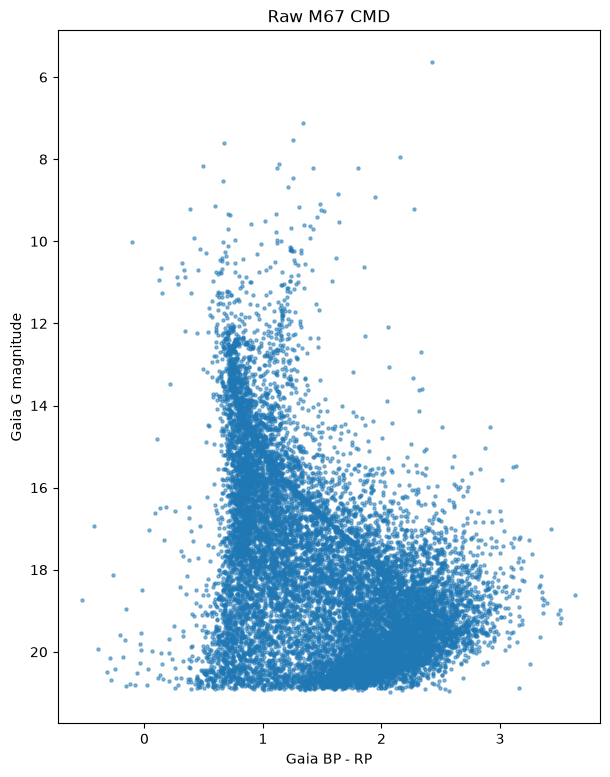

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 9))

plt.scatter(
    gaia["bp_rp"],
    gaia["phot_g_mean_mag"],
    s=5,
    alpha=0.5
)

plt.xlabel("Gaia BP - RP")
plt.ylabel("Gaia G magnitude")
plt.title("Raw M67 CMD")
plt.gca().invert_yaxis()
plt.show()

In [4]:
gaia_clean = gaia.dropna(
    subset=["bp_rp", "phot_g_mean_mag", "parallax", "pmra", "pmdec"]
)

m67 = gaia_clean[
    (gaia_clean["parallax"] > 0.7) &
    (gaia_clean["parallax"] < 1.5) &
    (gaia_clean["pmra"] > -14) &
    (gaia_clean["pmra"] < -7) &
    (gaia_clean["pmdec"] > -6) &
    (gaia_clean["pmdec"] < 1)
]

print("Raw stars:", len(gaia))
print("Filtered stars:", len(m67))

Raw stars: 14813
Filtered stars: 2034


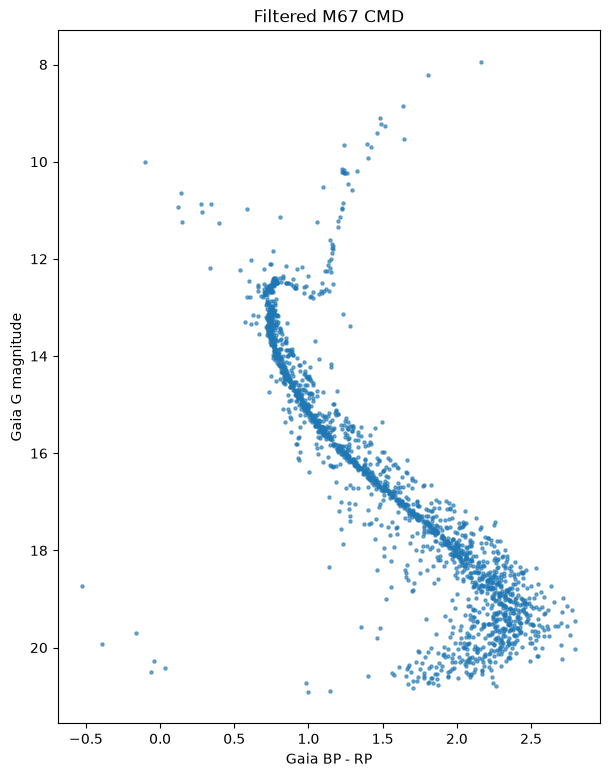

In [5]:
plt.figure(figsize=(7, 9))

plt.scatter(
    m67["bp_rp"],
    m67["phot_g_mean_mag"],
    s=5,
    alpha=0.6
)

plt.xlabel("Gaia BP - RP")
plt.ylabel("Gaia G magnitude")
plt.title("Filtered M67 CMD")
plt.gca().invert_yaxis()
plt.show()

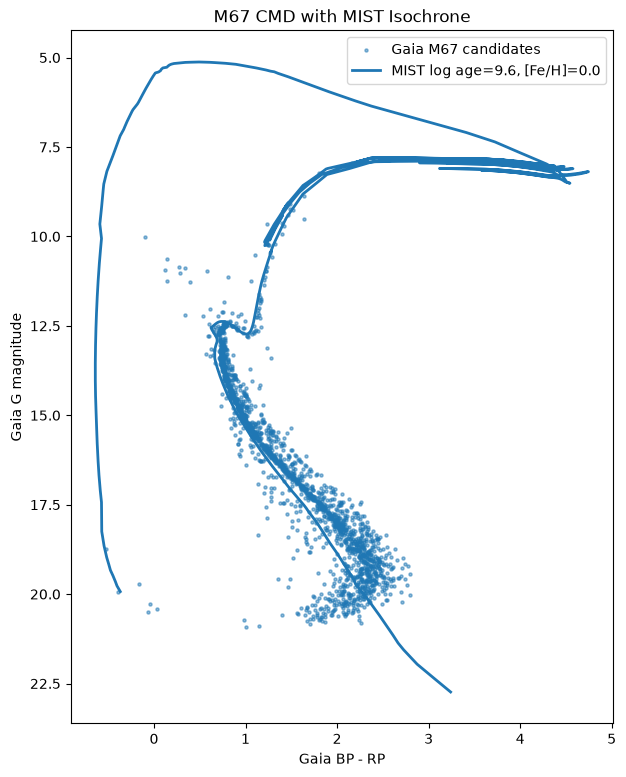

In [6]:
import numpy as np

log_age = 9.60
feh = 0.0
distance_pc = 857

A_G = 0.0
E_BP_RP = 0.0

iso = mist.isochrone(log_age, feh)

mist_color = iso["BP_mag"] - iso["RP_mag"]
mist_G_abs = iso["G_mag"]

distance_modulus = 5 * np.log10(distance_pc) - 5

mist_color_obs = mist_color + E_BP_RP
mist_G_app = mist_G_abs + distance_modulus + A_G

plt.figure(figsize=(7, 9))

plt.scatter(
    m67["bp_rp"],
    m67["phot_g_mean_mag"],
    s=5,
    alpha=0.5,
    label="Gaia M67 candidates"
)

plt.plot(
    mist_color_obs,
    mist_G_app,
    linewidth=2,
    label=f"MIST log age={log_age}, [Fe/H]={feh}"
)

plt.xlabel("Gaia BP - RP")
plt.ylabel("Gaia G magnitude")
plt.title("M67 CMD with MIST Isochrone")
plt.gca().invert_yaxis()
plt.legend()
plt.show()

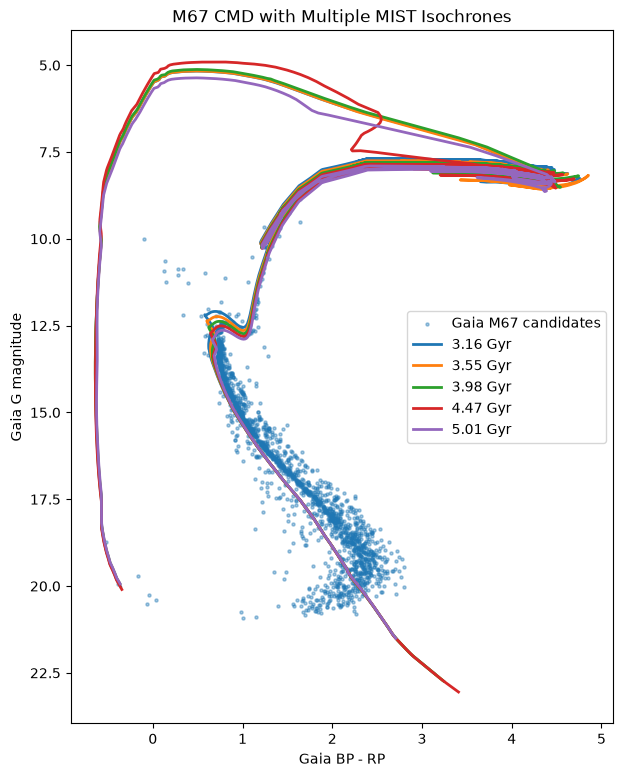

In [7]:
ages_to_try = [9.50, 9.55, 9.60, 9.65, 9.70]

distance_modulus = 5 * np.log10(distance_pc) - 5

plt.figure(figsize=(7, 9))

plt.scatter(
    m67["bp_rp"],
    m67["phot_g_mean_mag"],
    s=5,
    alpha=0.4,
    label="Gaia M67 candidates"
)

for log_age in ages_to_try:
    iso = mist.isochrone(log_age, feh)

    mist_color = iso["BP_mag"] - iso["RP_mag"]
    mist_G_abs = iso["G_mag"]

    mist_color_obs = mist_color + E_BP_RP
    mist_G_app = mist_G_abs + distance_modulus + A_G

    age_gyr = (10 ** log_age) / 1e9

    plt.plot(
        mist_color_obs,
        mist_G_app,
        linewidth=2,
        label=f"{age_gyr:.2f} Gyr"
    )

plt.xlabel("Gaia BP - RP")
plt.ylabel("Gaia G magnitude")
plt.title("M67 CMD with Multiple MIST Isochrones")
plt.gca().invert_yaxis()
plt.legend()
plt.show()